In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
import joblib

In [112]:
df = pd.read_csv("C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Prediction\\Hyderabad\\Hyderabad Property Data.csv")

In [113]:
print("size of df : " , df.shape)
print("df type of each colum in the df : ",df.dtypes)
print("no of null values :", df.isnull().sum())
duplicate_values = df.duplicated().sum()
print("no of duplicated values",duplicate_values)
numerical_summary = df.describe().T
print("Summary statistics for numerical columns:")
print(numerical_summary)

# Add mode and quartiles
mode = df.mode().iloc[0]  # Mode of each column
numerical_summary['Mode'] = mode
print("Updated summary statistics with mode:")
print(numerical_summary)


size of df :  (4913, 12)
df type of each colum in the df :  Locality          object
Quarter           object
Price Range       object
Average Price     object
Q-o-Q             object
Growth Type      float64
City             float64
Type             float64
Unnamed: 8       float64
Unnamed: 9       float64
Unnamed: 10       object
Unnamed: 11      float64
dtype: object
no of null values : Locality          181
Quarter           181
Price Range       181
Average Price     181
Q-o-Q             202
Growth Type      4913
City             4913
Type             4913
Unnamed: 8       4913
Unnamed: 9       4913
Unnamed: 10      4905
Unnamed: 11      4913
dtype: int64
no of duplicated values 180
Summary statistics for numerical columns:
             count  mean  std  min  25%  50%  75%  max
Growth Type    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
City           0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
Type           0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
Unnamed: 8     0.0   NaN  NaN  NaN  NaN

In [114]:
df.describe()

,Growth Type,City,Type,Unnamed: 8,Unnamed: 9,Unnamed: 11
count,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN


In [115]:
# df.drop(columns=['City','Type'])
df

,Locality,Quarter,Price Range,Average Price,Q-o-Q,Growth Type,City,Type,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,100 Feet Road,Oct-Dec 2024,6909-11526,"9,218",4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100 Feet Road,Jul-Sep 2024,7027-12134,"9,581",-,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100 Feet Road,Apr-Jun 2024,6500 - 11000,"8,750",8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100 Feet Road,Jan-Mar 2024,5850-10338,"8,094",6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100 Feet Road,Oct-Dec 2023,5500 - 9800,"7,650",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
4908,Yousufguda Main Road,Jul-Sep 2019,3900-7600,"5,800",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4909,Yousufguda Main Road,Apr-Jun 2019,3800-7500,"5,725",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4910,Yousufguda Main Road,Jan-Mar 2019,3700-7400,"5,650",1.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4911,Yousufguda Main Road,Oct-Dec 2018,3600-7300,"5,575",1.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [116]:
df.drop(columns=['Q-o-Q','Growth Type'], inplace= True)

In [117]:
df

,Locality,Quarter,Price Range,Average Price,City,Type,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,100 Feet Road,Oct-Dec 2024,6909-11526,"9,218",NaN,NaN,NaN,NaN,NaN,NaN
1,100 Feet Road,Jul-Sep 2024,7027-12134,"9,581",NaN,NaN,NaN,NaN,NaN,NaN
2,100 Feet Road,Apr-Jun 2024,6500 - 11000,"8,750",NaN,NaN,NaN,NaN,NaN,NaN
3,100 Feet Road,Jan-Mar 2024,5850-10338,"8,094",NaN,NaN,NaN,NaN,NaN,NaN
4,100 Feet Road,Oct-Dec 2023,5500 - 9800,"7,650",NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
4908,Yousufguda Main Road,Jul-Sep 2019,3900-7600,"5,800",NaN,NaN,NaN,NaN,NaN,NaN
4909,Yousufguda Main Road,Apr-Jun 2019,3800-7500,"5,725",NaN,NaN,NaN,NaN,NaN,NaN
4910,Yousufguda Main Road,Jan-Mar 2019,3700-7400,"5,650",NaN,NaN,NaN,NaN,NaN,NaN
4911,Yousufguda Main Road,Oct-Dec 2018,3600-7300,"5,575",NaN,NaN,NaN,NaN,NaN,NaN


In [118]:
df['Month'] = df['Quarter'].str.split(' ', expand=True)[0] 
df['Year'] = df['Quarter'].str.split(' ', expand=True)[1]   

In [119]:
df.drop(columns=['Quarter'])

,Locality,Price Range,Average Price,City,Type,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Month,Year
0,100 Feet Road,6909-11526,"9,218",NaN,NaN,NaN,NaN,NaN,NaN,Oct-Dec,2024
1,100 Feet Road,7027-12134,"9,581",NaN,NaN,NaN,NaN,NaN,NaN,Jul-Sep,2024
2,100 Feet Road,6500 - 11000,"8,750",NaN,NaN,NaN,NaN,NaN,NaN,Apr-Jun,2024
3,100 Feet Road,5850-10338,"8,094",NaN,NaN,NaN,NaN,NaN,NaN,Jan-Mar,2024
4,100 Feet Road,5500 - 9800,"7,650",NaN,NaN,NaN,NaN,NaN,NaN,Oct-Dec,2023
...,...,...,...,...,...,...,...,...,...,...,...
4908,Yousufguda Main Road,3900-7600,"5,800",NaN,NaN,NaN,NaN,NaN,NaN,Jul-Sep,2019
4909,Yousufguda Main Road,3800-7500,"5,725",NaN,NaN,NaN,NaN,NaN,NaN,Apr-Jun,2019
4910,Yousufguda Main Road,3700-7400,"5,650",NaN,NaN,NaN,NaN,NaN,NaN,Jan-Mar,2019
4911,Yousufguda Main Road,3600-7300,"5,575",NaN,NaN,NaN,NaN,NaN,NaN,Oct-Dec,2018


In [120]:
df.drop(columns=['Quarter'],inplace=True)

In [121]:
df

,Locality,Price Range,Average Price,City,Type,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Month,Year
0,100 Feet Road,6909-11526,"9,218",NaN,NaN,NaN,NaN,NaN,NaN,Oct-Dec,2024
1,100 Feet Road,7027-12134,"9,581",NaN,NaN,NaN,NaN,NaN,NaN,Jul-Sep,2024
2,100 Feet Road,6500 - 11000,"8,750",NaN,NaN,NaN,NaN,NaN,NaN,Apr-Jun,2024
3,100 Feet Road,5850-10338,"8,094",NaN,NaN,NaN,NaN,NaN,NaN,Jan-Mar,2024
4,100 Feet Road,5500 - 9800,"7,650",NaN,NaN,NaN,NaN,NaN,NaN,Oct-Dec,2023
...,...,...,...,...,...,...,...,...,...,...,...
4908,Yousufguda Main Road,3900-7600,"5,800",NaN,NaN,NaN,NaN,NaN,NaN,Jul-Sep,2019
4909,Yousufguda Main Road,3800-7500,"5,725",NaN,NaN,NaN,NaN,NaN,NaN,Apr-Jun,2019
4910,Yousufguda Main Road,3700-7400,"5,650",NaN,NaN,NaN,NaN,NaN,NaN,Jan-Mar,2019
4911,Yousufguda Main Road,3600-7300,"5,575",NaN,NaN,NaN,NaN,NaN,NaN,Oct-Dec,2018


In [122]:
# from sklearn.preprocessing import LabelEncoder
# location_encoder = LabelEncoder()
# df['Locality'] = location_encoder.fit_transform(df['Locality'])
# print(df.head)
# joblib.dump(location_encoder,'location_encoding_test.pkl')

In [123]:
import numpy as np
df['Average Price'] = df['Average Price'].replace('-', np.nan)
df['Average Price'] = df['Average Price'].str.replace(',', '').astype(float)

In [124]:
df['Price Range'] = df['Price Range'].replace('-', '0-0').fillna('0-0')
df['Min Price'] = df['Price Range'].str.split('-').str[0].str.replace(',', '').replace('', '0').astype(float)
df['Max Price'] = df['Price Range'].str.split('-').str[1].str.replace(',', '').replace('', '0').astype(float)


In [125]:
print(df.isnull().sum())
df = df.dropna(subset=['Average Price', 'Min Price', 'Max Price'])


Locality          181
Price Range         0
Average Price     188
City             4913
Type             4913
Unnamed: 8       4913
Unnamed: 9       4913
Unnamed: 10      4905
Unnamed: 11      4913
Month             181
Year              181
Min Price           0
Max Price           0
dtype: int64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_13564\1517563059.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month_Encoded'] = df['Month'].map({


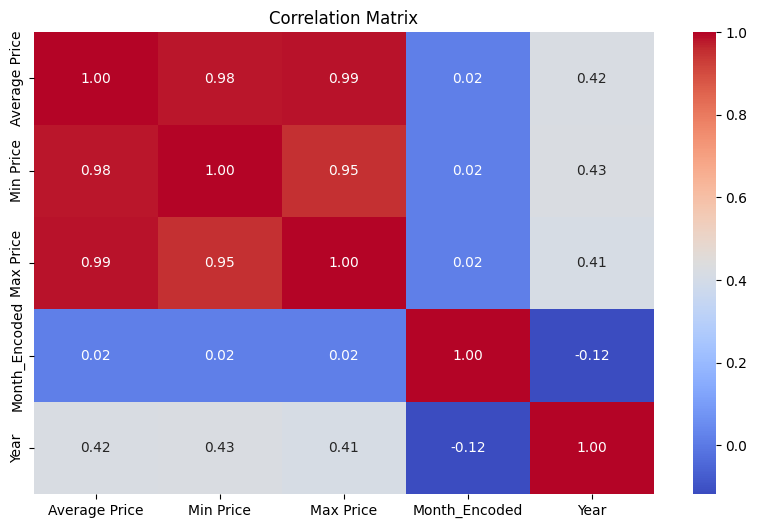

In [126]:
df['Month_Encoded'] = df['Month'].map({
    'Jan-Mar': 1,
    'Apr-Jun': 2,
    'Jul-Sep': 3,
    'Oct-Dec': 4
})
# df['City_Encoded'] = df['City'].factorize()[0]
# df['Type_Encoded'] = df['Type'].factorize()[0]

# Select numerical columns for correlation analysis
numerical_cols = ['Average Price', 'Min Price', 'Max Price', 'Month_Encoded', 'Year']

# Compute the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Visualize the correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [127]:
df.drop(columns=['Price Range','City','Type'],inplace=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13564\1663544092.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['Price Range','City','Type'],inplace=True)


In [128]:
df

,Locality,Average Price,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Month,Year,Min Price,Max Price,Month_Encoded
0,100 Feet Road,9218.0,NaN,NaN,NaN,NaN,Oct-Dec,2024,6909.0,11526.0,4
1,100 Feet Road,9581.0,NaN,NaN,NaN,NaN,Jul-Sep,2024,7027.0,12134.0,3
2,100 Feet Road,8750.0,NaN,NaN,NaN,NaN,Apr-Jun,2024,6500.0,11000.0,2
3,100 Feet Road,8094.0,NaN,NaN,NaN,NaN,Jan-Mar,2024,5850.0,10338.0,1
4,100 Feet Road,7650.0,NaN,NaN,NaN,NaN,Oct-Dec,2023,5500.0,9800.0,4
...,...,...,...,...,...,...,...,...,...,...,...
4908,Yousufguda Main Road,5800.0,NaN,NaN,NaN,NaN,Jul-Sep,2019,3900.0,7600.0,3
4909,Yousufguda Main Road,5725.0,NaN,NaN,NaN,NaN,Apr-Jun,2019,3800.0,7500.0,2
4910,Yousufguda Main Road,5650.0,NaN,NaN,NaN,NaN,Jan-Mar,2019,3700.0,7400.0,1
4911,Yousufguda Main Road,5575.0,NaN,NaN,NaN,NaN,Oct-Dec,2018,3600.0,7300.0,4


In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4725 entries, 0 to 4912
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Locality       4725 non-null   object 
 1   Average Price  4725 non-null   float64
 2   Unnamed: 8     0 non-null      float64
 3   Unnamed: 9     0 non-null      float64
 4   Unnamed: 10    8 non-null      object 
 5   Unnamed: 11    0 non-null      float64
 6   Month          4725 non-null   object 
 7   Year           4725 non-null   object 
 8   Min Price      4725 non-null   float64
 9   Max Price      4725 non-null   float64
 10  Month_Encoded  4725 non-null   int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 443.0+ KB


In [130]:
df['Year'] = df['Year'].astype('float64')


C:\Users\Administrator\AppData\Local\Temp\ipykernel_13564\2649418009.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Year'].astype('float64')


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4725 entries, 0 to 4912
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Locality       4725 non-null   object 
 1   Average Price  4725 non-null   float64
 2   Unnamed: 8     0 non-null      float64
 3   Unnamed: 9     0 non-null      float64
 4   Unnamed: 10    8 non-null      object 
 5   Unnamed: 11    0 non-null      float64
 6   Month          4725 non-null   object 
 7   Year           4725 non-null   float64
 8   Min Price      4725 non-null   float64
 9   Max Price      4725 non-null   float64
 10  Month_Encoded  4725 non-null   int64  
dtypes: float64(7), int64(1), object(3)
memory usage: 443.0+ KB


In [132]:
df

,Locality,Average Price,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Month,Year,Min Price,Max Price,Month_Encoded
0,100 Feet Road,9218.0,NaN,NaN,NaN,NaN,Oct-Dec,2024.0,6909.0,11526.0,4
1,100 Feet Road,9581.0,NaN,NaN,NaN,NaN,Jul-Sep,2024.0,7027.0,12134.0,3
2,100 Feet Road,8750.0,NaN,NaN,NaN,NaN,Apr-Jun,2024.0,6500.0,11000.0,2
3,100 Feet Road,8094.0,NaN,NaN,NaN,NaN,Jan-Mar,2024.0,5850.0,10338.0,1
4,100 Feet Road,7650.0,NaN,NaN,NaN,NaN,Oct-Dec,2023.0,5500.0,9800.0,4
...,...,...,...,...,...,...,...,...,...,...,...
4908,Yousufguda Main Road,5800.0,NaN,NaN,NaN,NaN,Jul-Sep,2019.0,3900.0,7600.0,3
4909,Yousufguda Main Road,5725.0,NaN,NaN,NaN,NaN,Apr-Jun,2019.0,3800.0,7500.0,2
4910,Yousufguda Main Road,5650.0,NaN,NaN,NaN,NaN,Jan-Mar,2019.0,3700.0,7400.0,1
4911,Yousufguda Main Road,5575.0,NaN,NaN,NaN,NaN,Oct-Dec,2018.0,3600.0,7300.0,4


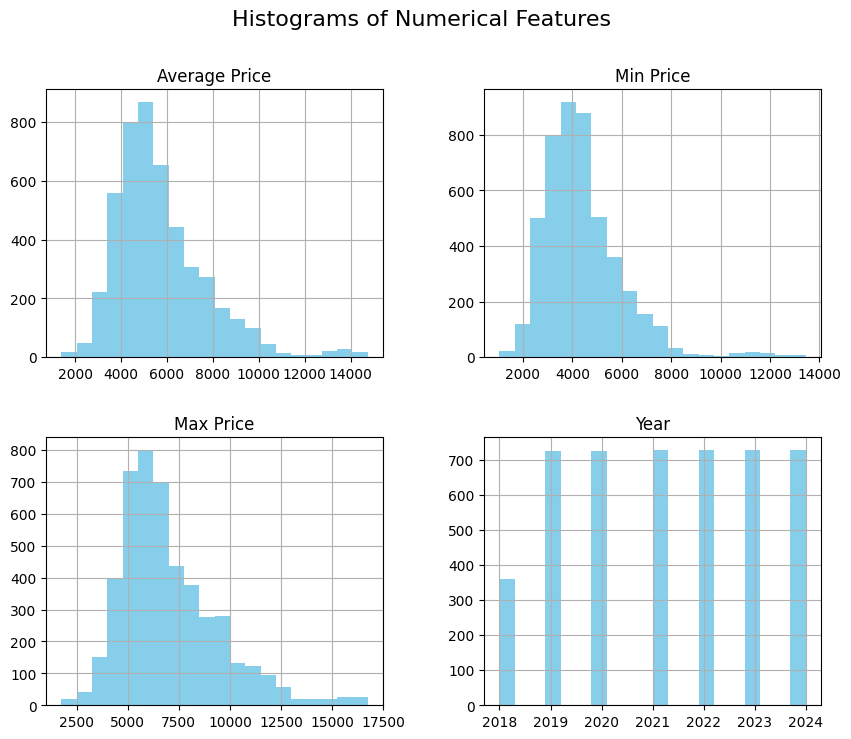

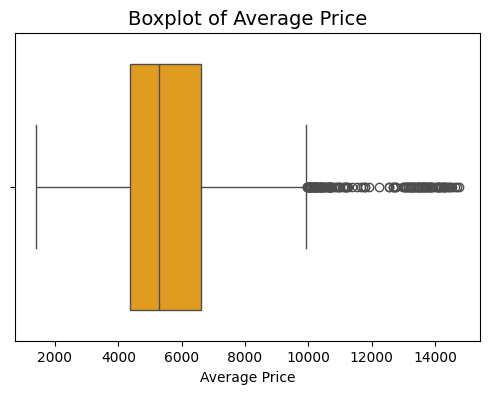

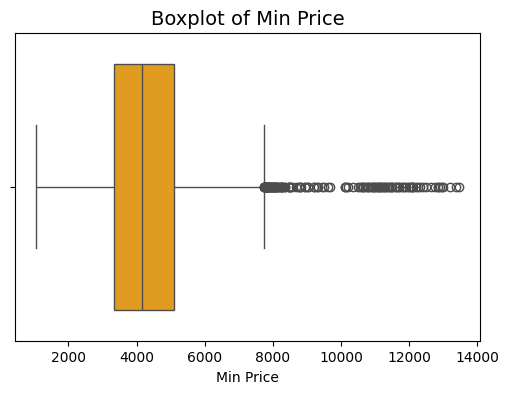

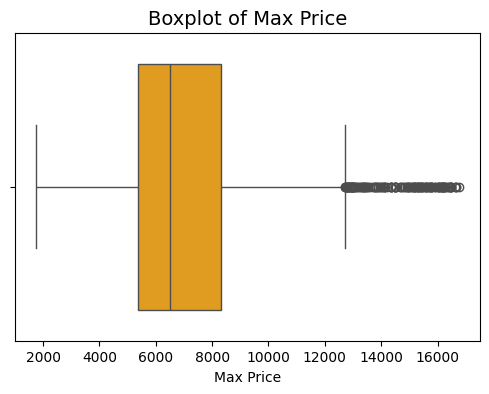

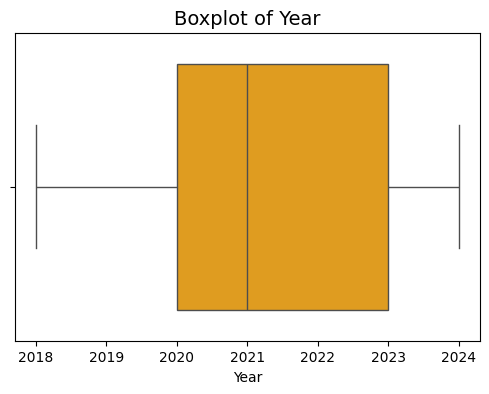

In [133]:
# Plot histograms for numerical columns
numerical_features = ['Average Price', 'Min Price', 'Max Price', 'Year']
df[numerical_features].hist(bins=20, figsize=(10, 8), color='skyblue')
plt.suptitle('Histograms of Numerical Features', fontsize=16)
plt.show()

# Box plots for numerical columns
for feature in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[feature], color='orange')
    plt.title(f'Boxplot of {feature}', fontsize=14)
    plt.show()


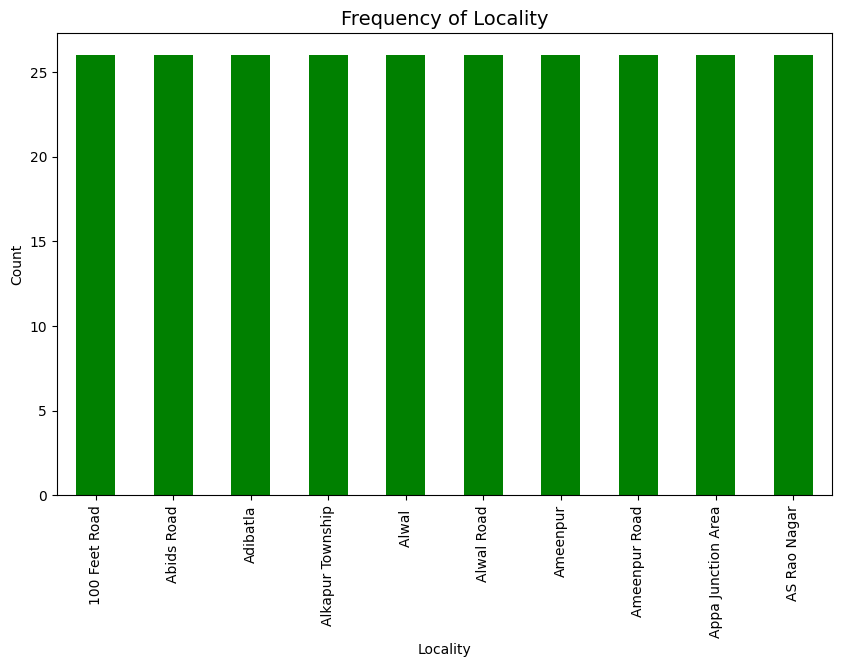

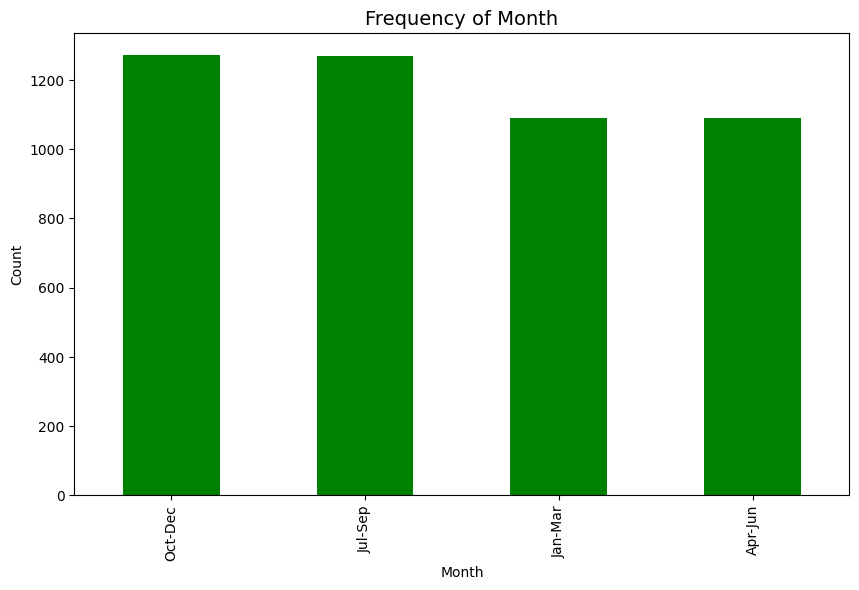

In [134]:
# Frequency tables and bar charts for categorical columns
categorical_features = ['Locality', 'Month']
for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    df[feature].value_counts().head(10).plot(kind='bar', color='green')
    plt.title(f'Frequency of {feature}', fontsize=14)
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()


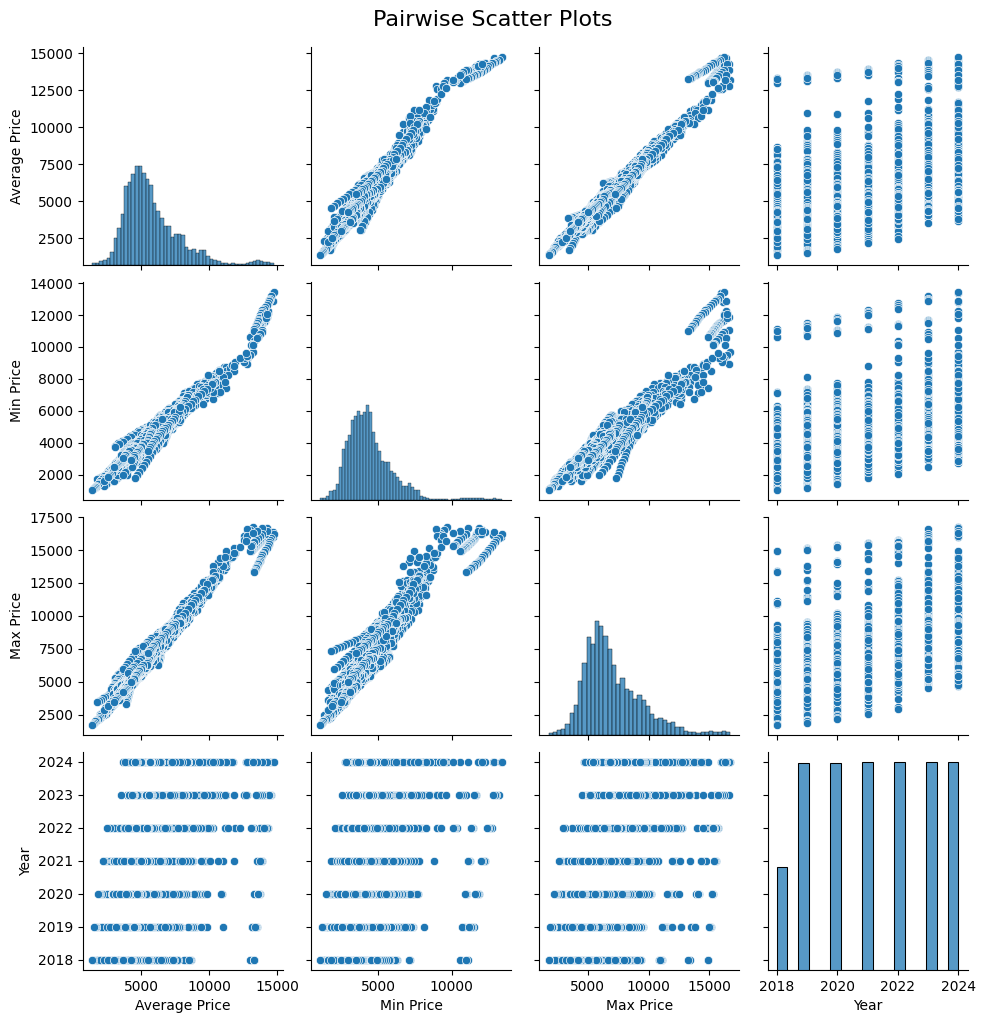

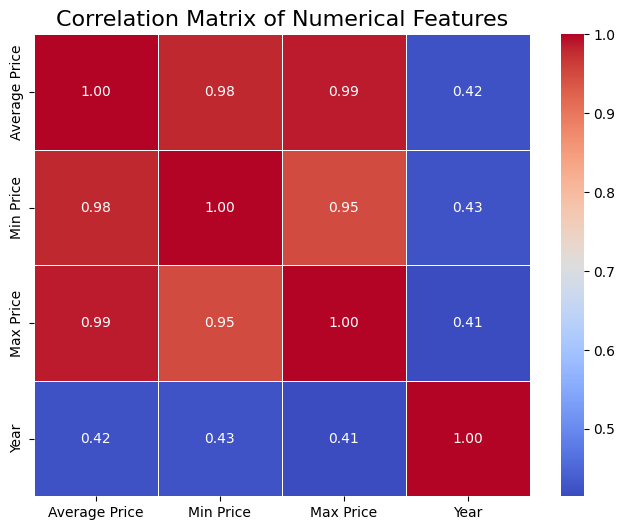

In [135]:
# Scatter plot to visualize relationships between numerical features
sns.pairplot(df[numerical_features])
plt.suptitle('Pairwise Scatter Plots', y=1.02, fontsize=16)
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_13564\1340889095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y=feature, data=df, palette='Set2')


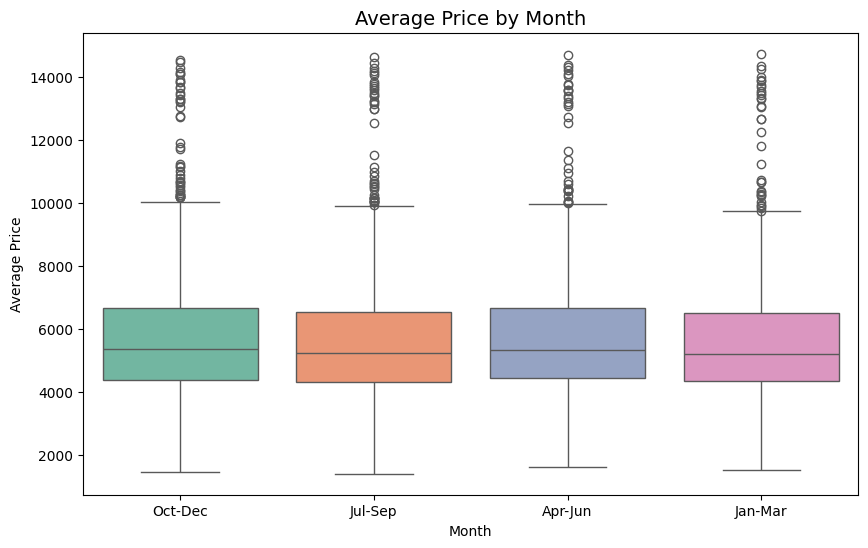

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13564\1340889095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y=feature, data=df, palette='Set2')


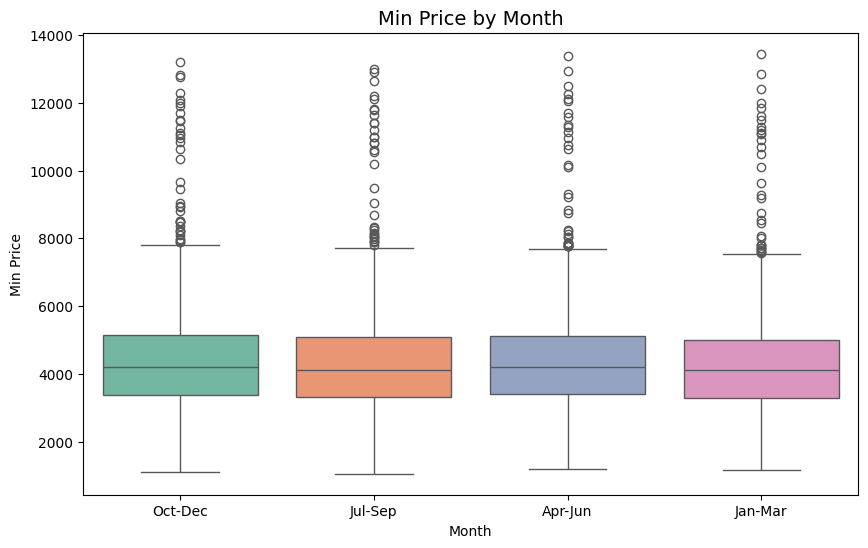

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13564\1340889095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y=feature, data=df, palette='Set2')


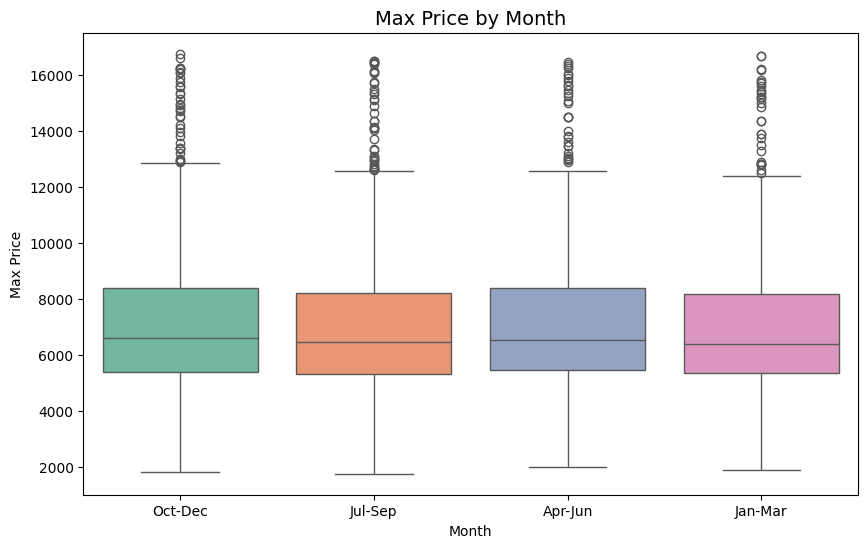

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13564\1340889095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y=feature, data=df, palette='Set2')


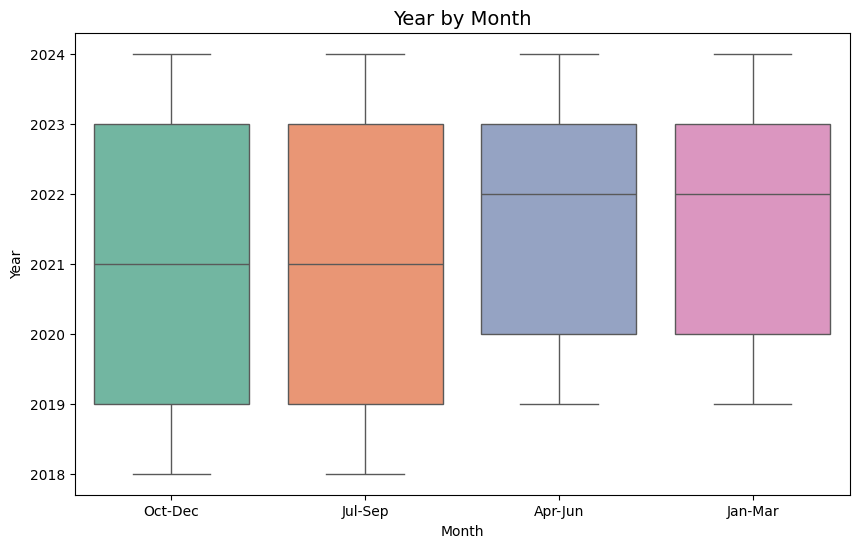

In [136]:
# Box plots to compare numerical features across categories
for feature in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Month', y=feature, data=df, palette='Set2')
    plt.title(f'{feature} by Month', fontsize=14)
    plt.xlabel('Month')
    plt.ylabel(feature)
    plt.show()


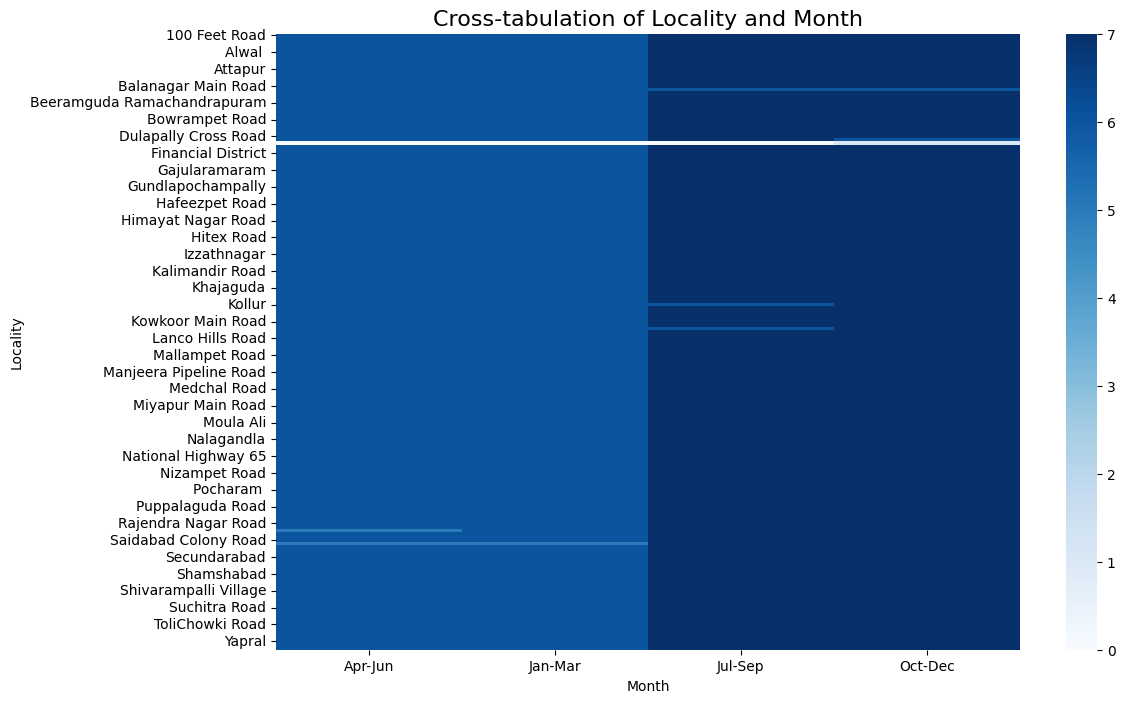

In [137]:
# Cross-tabulation and heatmap
cross_tab = pd.crosstab(df['Locality'], df['Month'])
plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab, cmap='Blues', annot=False, cbar=True)
plt.title('Cross-tabulation of Locality and Month', fontsize=16)
plt.show()


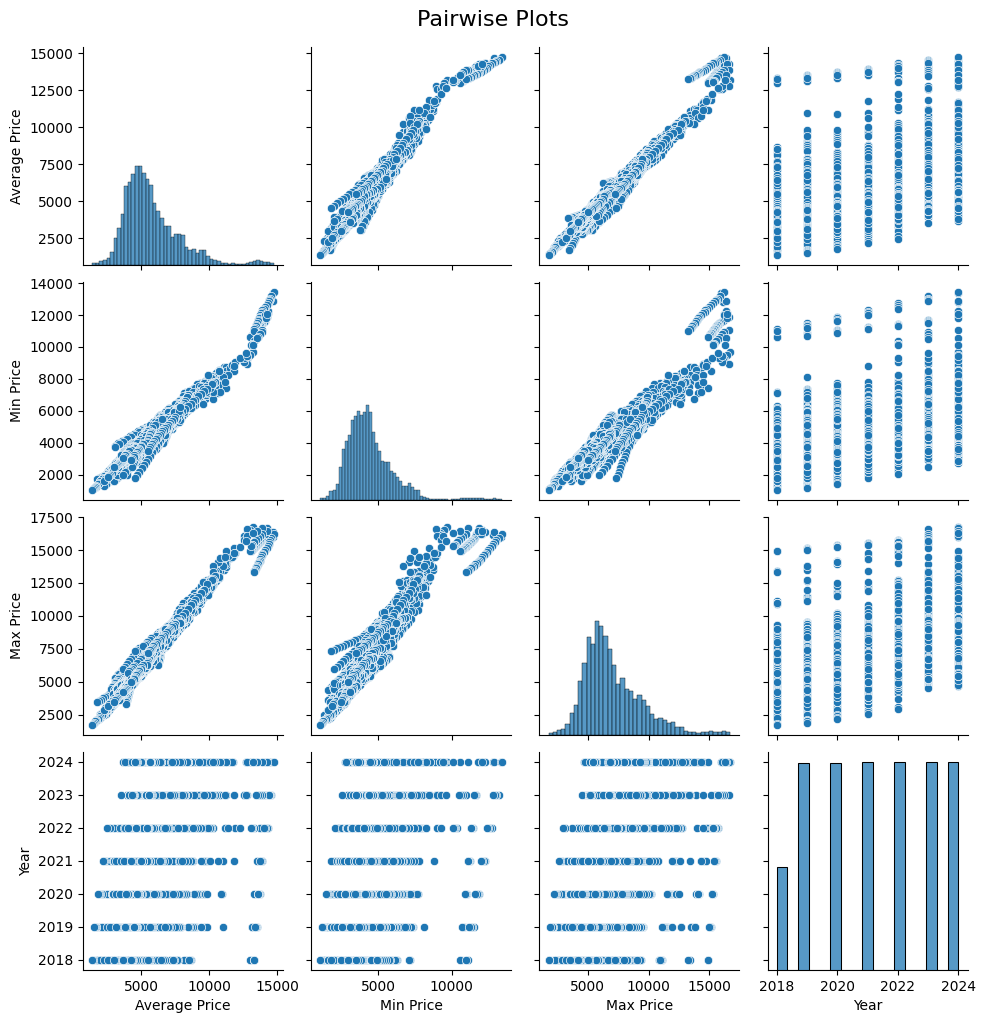

In [138]:
# Pair plot for selected features
selected_features = ['Average Price', 'Min Price', 'Max Price', 'Year']
sns.pairplot(df[selected_features])
plt.suptitle('Pairwise Plots', y=1.02, fontsize=16)
plt.show()


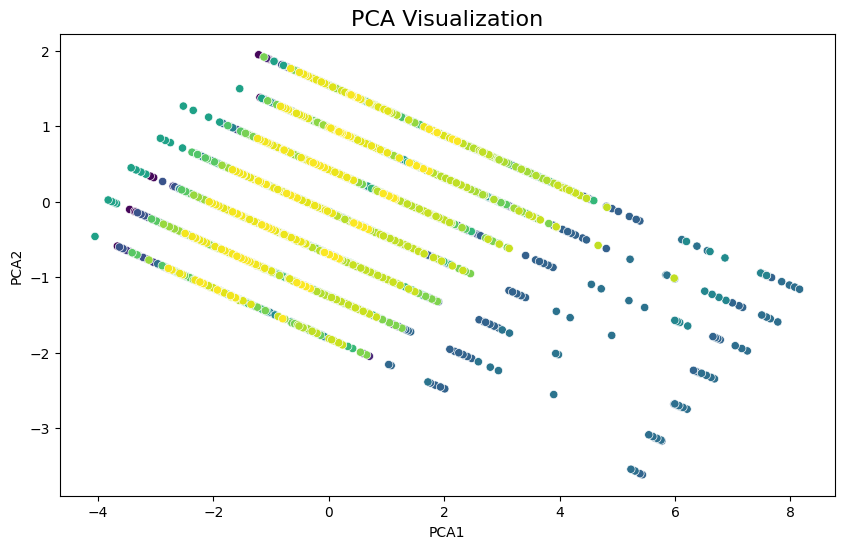

In [139]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(df[numerical_features])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(numerical_scaled)

pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])
pca_df['Locality'] = df['Locality']

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Locality', data=pca_df, legend=False, palette='viridis')
plt.title('PCA Visualization', fontsize=16)
plt.show()


In [140]:
df = df.drop(df[df['Month'] == 'April-June'].index)

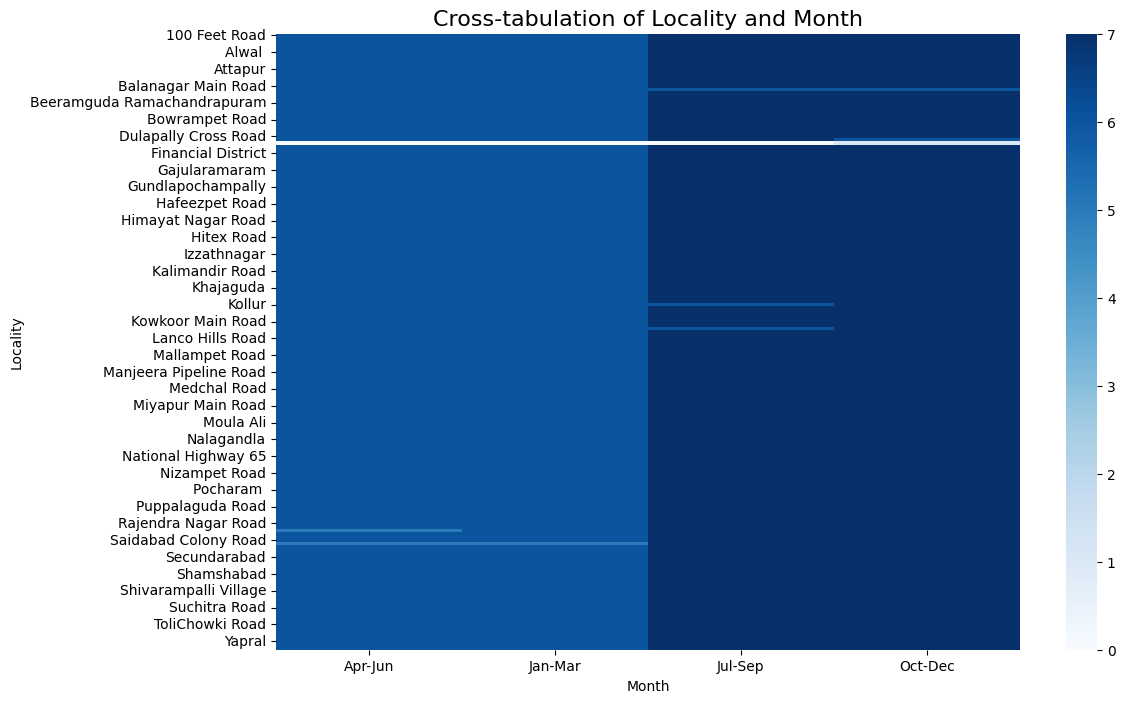

In [141]:
# Cross-tabulation and heatmap
cross_tab = pd.crosstab(df['Locality'], df['Month'])
plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab, cmap='Blues', annot=False, cbar=True)
plt.title('Cross-tabulation of Locality and Month', fontsize=16)
plt.show()

In [142]:
from sklearn.preprocessing import MinMaxScaler
columns_to_scale = ['Average Price', 'Min Price', 'Max Price']
scaler = MinMaxScaler(feature_range=(1, 10))
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])
joblib.dump(scaler,'Hyderabad_price_scaling.pkl')

['Hyderabad_price_scaling.pkl']

In [143]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Locality'] = encoder.fit_transform(df['Locality'])
scaler = MinMaxScaler(feature_range=(1,10))
df[['Locality']] = scaler.fit_transform(df[['Locality']])
joblib.dump(encoder,'Hyderabad_locality_encoding.pkl')
joblib.dump(scaler,'Hyderabad_locality_scaling.pkl')


['Hyderabad_locality_scaling.pkl']

In [144]:
df

,Locality,Average Price,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Month,Year,Min Price,Max Price,Month_Encoded
0,1.0,6.270562,NaN,NaN,NaN,NaN,Oct-Dec,2024.0,5.252500,6.865209,4
1,1.0,6.515281,NaN,NaN,NaN,NaN,Jul-Sep,2024.0,5.338145,7.229985,3
2,1.0,5.955056,NaN,NaN,NaN,NaN,Apr-Jun,2024.0,4.955645,6.549630,2
3,1.0,5.512809,NaN,NaN,NaN,NaN,Jan-Mar,2024.0,4.483871,6.152457,1
4,1.0,5.213483,NaN,NaN,NaN,NaN,Oct-Dec,2023.0,4.229839,5.829678,4
...,...,...,...,...,...,...,...,...,...,...,...
4908,10.0,3.966292,NaN,NaN,NaN,NaN,Jul-Sep,2019.0,3.068548,4.509766,3
4909,10.0,3.915730,NaN,NaN,NaN,NaN,Apr-Jun,2019.0,2.995968,4.449770,2
4910,10.0,3.865169,NaN,NaN,NaN,NaN,Jan-Mar,2019.0,2.923387,4.389774,1
4911,10.0,3.814607,NaN,NaN,NaN,NaN,Oct-Dec,2018.0,2.850806,4.329778,4


In [145]:
month_mapping = {
    "Jan-Mar": 1,
    "Apr-Jun": 2,
    "Jul-Sep": 3,
    "Oct-Dec": 4
}
df['Month_Mapped'] = df['Month'].map(month_mapping)

In [146]:
df

,Locality,Average Price,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Month,Year,Min Price,Max Price,Month_Encoded,Month_Mapped
0,1.0,6.270562,NaN,NaN,NaN,NaN,Oct-Dec,2024.0,5.252500,6.865209,4,4
1,1.0,6.515281,NaN,NaN,NaN,NaN,Jul-Sep,2024.0,5.338145,7.229985,3,3
2,1.0,5.955056,NaN,NaN,NaN,NaN,Apr-Jun,2024.0,4.955645,6.549630,2,2
3,1.0,5.512809,NaN,NaN,NaN,NaN,Jan-Mar,2024.0,4.483871,6.152457,1,1
4,1.0,5.213483,NaN,NaN,NaN,NaN,Oct-Dec,2023.0,4.229839,5.829678,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...
4908,10.0,3.966292,NaN,NaN,NaN,NaN,Jul-Sep,2019.0,3.068548,4.509766,3,3
4909,10.0,3.915730,NaN,NaN,NaN,NaN,Apr-Jun,2019.0,2.995968,4.449770,2,2
4910,10.0,3.865169,NaN,NaN,NaN,NaN,Jan-Mar,2019.0,2.923387,4.389774,1,1
4911,10.0,3.814607,NaN,NaN,NaN,NaN,Oct-Dec,2018.0,2.850806,4.329778,4,4


In [147]:
df.drop(columns=['Month'])

,Locality,Average Price,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Year,Min Price,Max Price,Month_Encoded,Month_Mapped
0,1.0,6.270562,NaN,NaN,NaN,NaN,2024.0,5.252500,6.865209,4,4
1,1.0,6.515281,NaN,NaN,NaN,NaN,2024.0,5.338145,7.229985,3,3
2,1.0,5.955056,NaN,NaN,NaN,NaN,2024.0,4.955645,6.549630,2,2
3,1.0,5.512809,NaN,NaN,NaN,NaN,2024.0,4.483871,6.152457,1,1
4,1.0,5.213483,NaN,NaN,NaN,NaN,2023.0,4.229839,5.829678,4,4
...,...,...,...,...,...,...,...,...,...,...,...
4908,10.0,3.966292,NaN,NaN,NaN,NaN,2019.0,3.068548,4.509766,3,3
4909,10.0,3.915730,NaN,NaN,NaN,NaN,2019.0,2.995968,4.449770,2,2
4910,10.0,3.865169,NaN,NaN,NaN,NaN,2019.0,2.923387,4.389774,1,1
4911,10.0,3.814607,NaN,NaN,NaN,NaN,2018.0,2.850806,4.329778,4,4


In [148]:
df['Year_sin'] = np.sin(2 * np.pi * (df['Year'] - df['Year'].min()) / (df['Year'].max() - df['Year'].min()))
df['Year_cos'] = np.cos(2 * np.pi * (df['Year'] - df['Year'].min()) / (df['Year'].max() - df['Year'].min()))


In [149]:
df

,Locality,Average Price,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Month,Year,Min Price,Max Price,Month_Encoded,Month_Mapped,Year_sin,Year_cos
0,1.0,6.270562,NaN,NaN,NaN,NaN,Oct-Dec,2024.0,5.252500,6.865209,4,4,-2.449294e-16,1.0
1,1.0,6.515281,NaN,NaN,NaN,NaN,Jul-Sep,2024.0,5.338145,7.229985,3,3,-2.449294e-16,1.0
2,1.0,5.955056,NaN,NaN,NaN,NaN,Apr-Jun,2024.0,4.955645,6.549630,2,2,-2.449294e-16,1.0
3,1.0,5.512809,NaN,NaN,NaN,NaN,Jan-Mar,2024.0,4.483871,6.152457,1,1,-2.449294e-16,1.0
4,1.0,5.213483,NaN,NaN,NaN,NaN,Oct-Dec,2023.0,4.229839,5.829678,4,4,-8.660254e-01,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4908,10.0,3.966292,NaN,NaN,NaN,NaN,Jul-Sep,2019.0,3.068548,4.509766,3,3,8.660254e-01,0.5
4909,10.0,3.915730,NaN,NaN,NaN,NaN,Apr-Jun,2019.0,2.995968,4.449770,2,2,8.660254e-01,0.5
4910,10.0,3.865169,NaN,NaN,NaN,NaN,Jan-Mar,2019.0,2.923387,4.389774,1,1,8.660254e-01,0.5
4911,10.0,3.814607,NaN,NaN,NaN,NaN,Oct-Dec,2018.0,2.850806,4.329778,4,4,0.000000e+00,1.0


In [150]:
df.drop(columns=['Year','Month','Month_Mapped'],inplace=True)

In [151]:
# df.drop(columns=['Month_Mapped'],inplace=True)

In [152]:
df

,Locality,Average Price,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Min Price,Max Price,Month_Encoded,Year_sin,Year_cos
0,1.0,6.270562,NaN,NaN,NaN,NaN,5.252500,6.865209,4,-2.449294e-16,1.0
1,1.0,6.515281,NaN,NaN,NaN,NaN,5.338145,7.229985,3,-2.449294e-16,1.0
2,1.0,5.955056,NaN,NaN,NaN,NaN,4.955645,6.549630,2,-2.449294e-16,1.0
3,1.0,5.512809,NaN,NaN,NaN,NaN,4.483871,6.152457,1,-2.449294e-16,1.0
4,1.0,5.213483,NaN,NaN,NaN,NaN,4.229839,5.829678,4,-8.660254e-01,0.5
...,...,...,...,...,...,...,...,...,...,...,...
4908,10.0,3.966292,NaN,NaN,NaN,NaN,3.068548,4.509766,3,8.660254e-01,0.5
4909,10.0,3.915730,NaN,NaN,NaN,NaN,2.995968,4.449770,2,8.660254e-01,0.5
4910,10.0,3.865169,NaN,NaN,NaN,NaN,2.923387,4.389774,1,8.660254e-01,0.5
4911,10.0,3.814607,NaN,NaN,NaN,NaN,2.850806,4.329778,4,0.000000e+00,1.0


In [153]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = ['Locality', 'Month_Encoded', 'Year_sin', 'Year_cos']
target = 'Average Price'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mape = (abs((y_test - y_pred) / y_test).mean()) * 100

print("Model Performance:") 
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R² Score: {r2}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")

import joblib
joblib.dump(model, "Hyderabad_Prediction_Model.pkl")


Model Performance:
Mean Absolute Error (MAE): 0.16660572855359362
Mean Squared Error (MSE): 0.05938792864671974
R² Score: 0.9676196850736584
Mean Absolute Percentage Error (MAPE): 4.4009882042976916%


['Hyderabad_Prediction_Model.pkl']

In [161]:
import pandas as pd
import numpy as np
import joblib

encoder = joblib.load('C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Prediction\\Hyderabad\\Hyderabad_locality_encoding.pkl')
scaler = joblib.load('C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Prediction\\Hyderabad\\Hyderabad_locality_scaling.pkl')
price_scaler = joblib.load('C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Prediction\\Hyderabad\\Hyderabad_price_scaling.pkl')
month_mapping = {
    'Jan-Mar': 1,
    'Apr-Jun': 2,
    'Jul-Sep': 3,
    'Oct-Dec': 4
}

def compute_year_sin_cos(year):
    base_year = 2019
    period = 6  
    year_index = year - base_year
    year_sin = np.sin(2 * np.pi * year_index / period)
    year_cos = np.cos(2 * np.pi * year_index / period)
    return year_sin, year_cos
def predict_price(location, year, quarter):
    location_encoded = encoder.transform([location])[0]
    location_scaled = scaler.transform([[location_encoded]])[0][0]  # Scaling after encoding

    month_encoded = month_mapping.get(quarter, None)
    if month_encoded is None:
        raise ValueError("Invalid quarter provided. Must be 'Jan-Mar', 'Apr-Jun', 'Jul-Sep', or 'Oct-Dec'.")

    year_sin, year_cos = compute_year_sin_cos(year)

    input_data = pd.DataFrame([[location_scaled, month_encoded, year_sin, year_cos]],
                              columns=['Locality', 'Month_Encoded', 'Year_sin', 'Year_cos'])

    model = joblib.load("C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Prediction\\Hyderabad\\Hyderabad_Prediction_Model.pkl")
    predicted_price_scaled = model.predict(input_data)[0]

    temp_data = [[predicted_price_scaled, None, None]]  
    predicted_price = price_scaler.inverse_transform(temp_data)[0][0]

    return predicted_price

location = '100 Feet Road'
year = 2028
quarter = 'Jul-Sep'

predicted_price = predict_price(location, year, quarter)
print(f"Predicted Average Price for {location} in {quarter} {year}: ₹{predicted_price}")


Predicted Average Price for 100 Feet Road in Jul-Sep 2028: ₹5910.530000000003


c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [162]:
import pandas as pd
import numpy as np
import joblib

encoder = joblib.load('C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Prediction\\Hyderabad\\Hyderabad_locality_encoding.pkl')
scaler = joblib.load('C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Prediction\\Hyderabad\\Hyderabad_locality_scaling.pkl')
price_scaler = joblib.load('C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Prediction\\Hyderabad\\Hyderabad_price_scaling.pkl')

month_mapping = {
    'Jan-Mar': 1,
    'Apr-Jun': 2,
    'Jul-Sep': 3,
    'Oct-Dec': 4
}

def compute_year_sin_cos(year):
    base_year = 2019
    period = 6  
    year_index = year - base_year
    year_sin = np.sin(2 * np.pi * year_index / period)
    year_cos = np.cos(2 * np.pi * year_index / period)
    return year_sin, year_cos

def predict_price(location, year, quarter, historical_data):
    # Encode and scale locality
    location_encoded = encoder.transform([location])[0]
    location_scaled = scaler.transform([[location_encoded]])[0][0]  # Scaling after encoding

    month_encoded = month_mapping.get(quarter, None)
    if month_encoded is None:
        raise ValueError("Invalid quarter provided. Must be 'Jan-Mar', 'Apr-Jun', 'Jul-Sep', or 'Oct-Dec'.")

    year_sin, year_cos = compute_year_sin_cos(year)

    input_data = pd.DataFrame([[location_scaled, month_encoded, year_sin, year_cos]],
                              columns=['Locality', 'Month_Encoded', 'Year_sin', 'Year_cos'])

    model = joblib.load("C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Prediction\\Hyderabad\\Hyderabad_Prediction_Model.pkl")

    predicted_price_scaled = model.predict(input_data)[0]

    temp_data = [[predicted_price_scaled, None, None]]  
    predicted_price = price_scaler.inverse_transform(temp_data)[0][0]

    locality_data = historical_data[historical_data['Locality'] == location]
    if locality_data.empty:
        raise ValueError(f"No historical data available for {location}.")
 
    locality_data['Price Range'] = locality_data['Price Range'].str.replace(',', '', regex=False)
    locality_data[['Min Price', 'Max Price']] = locality_data['Price Range'].str.split('-', expand=True).astype(float)
    locality_data['Average Price'] = locality_data['Average Price'].str.replace(',', '', regex=False).astype(float)

    min_price_factor = locality_data['Min Price'].mean() / locality_data['Average Price'].mean()
    max_price_factor = locality_data['Max Price'].mean() / locality_data['Average Price'].mean()

    predicted_min_price = predicted_price * min_price_factor
    predicted_max_price = predicted_price * max_price_factor

    return predicted_price, predicted_min_price, predicted_max_price


location = '100 Feet Road'
year = 2026
quarter = 'Jan-Mar'

historical_data = pd.read_csv("C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Prediction\\Hyderabad\\Hyderabad Property Data.csv")
predicted_price, predicted_min_price, predicted_max_price = predict_price(location, year, quarter, historical_data)

print(f"Predicted Average Price for {location} in {quarter} {year}: ₹{predicted_price:,.2f}")
print(f"Predicted Minimum Price for {location} in {quarter} {year}: ₹{predicted_min_price:,.2f}")
print(f"Predicted Maximum Price for {location} in {quarter} {year}: ₹{predicted_max_price:,.2f}")


c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Predicted Average Price for 100 Feet Road in Jan-Mar 2026: ₹5,199.03
Predicted Minimum Price for 100 Feet Road in Jan-Mar 2026: ₹3,774.82
Predicted Maximum Price for 100 Feet Road in Jan-Mar 2026: ₹6,623.18


C:\Users\Administrator\AppData\Local\Temp\ipykernel_13564\2082986560.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locality_data['Price Range'] = locality_data['Price Range'].str.replace(',', '', regex=False)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_13564\2082986560.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locality_data[['Min Price', 'Max Price']] = locality_data['Price Range'].str.split('-', expand=True).astype(float)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_13564\2